# Unemployment Analysis
**Task 2 - OASIS INFOBYTE Data Science Internship**

Analyze the unemployment rate in India before and during the COVID-19 pandemic.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

---
## 1. Load & Clean Dataset

In [2]:
df = pd.read_csv('Unemployment.csv')
df.columns = df.columns.str.strip()
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    str    
 1   Date                                     740 non-null    str    
 2   Frequency                                740 non-null    str    
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [4]:
df['Date'] = df['Date'].str.strip()
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df.dropna(subset=['Area'], inplace=True)
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2018.0,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019.0,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019.0,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019.0,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019.0,September


In [5]:
print(f'Shape: {df.shape}')
print(f'Date range: {df["Date"].min()} to {df["Date"].max()}')
print(f'Regions: {df["Region"].nunique()}')
print(f'Areas: {df["Area"].unique()}')

Shape: (740, 9)
Date range: 2019-05-31 00:00:00 to 2020-06-30 00:00:00
Regions: 28
Areas: <StringArray>
['Rural', 'Urban']
Length: 2, dtype: str


---
## 2. Exploratory Data Analysis

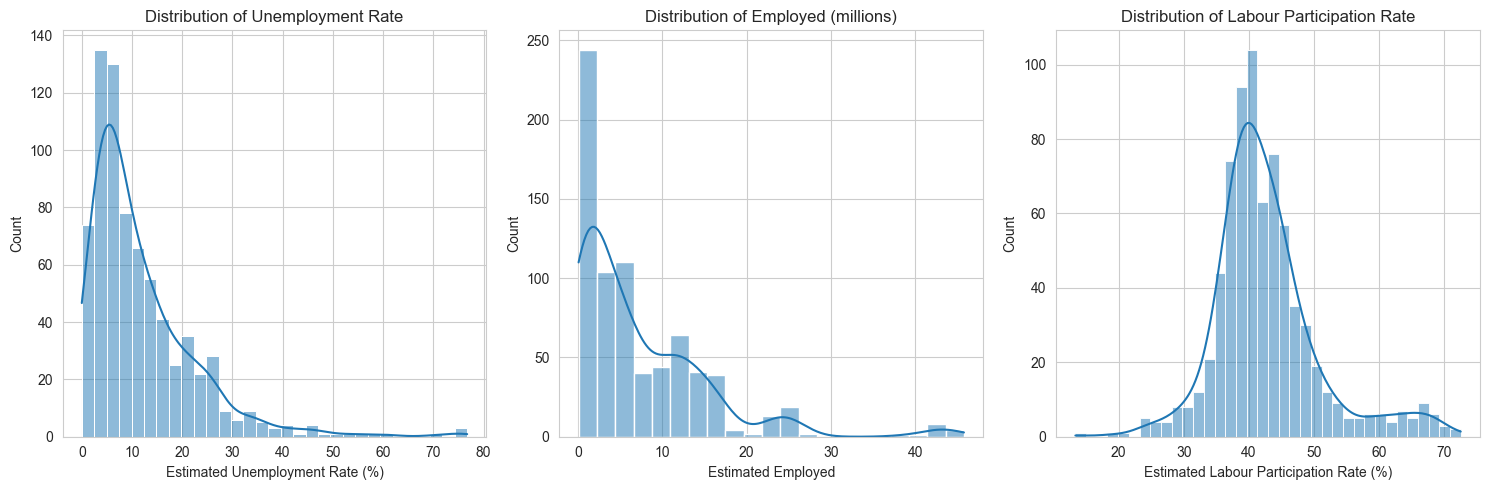

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['Estimated Unemployment Rate (%)'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Unemployment Rate')

sns.histplot(df['Estimated Employed'] / 1e6, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Employed (millions)')

sns.histplot(df['Estimated Labour Participation Rate (%)'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Labour Participation Rate')

plt.tight_layout()
plt.show()

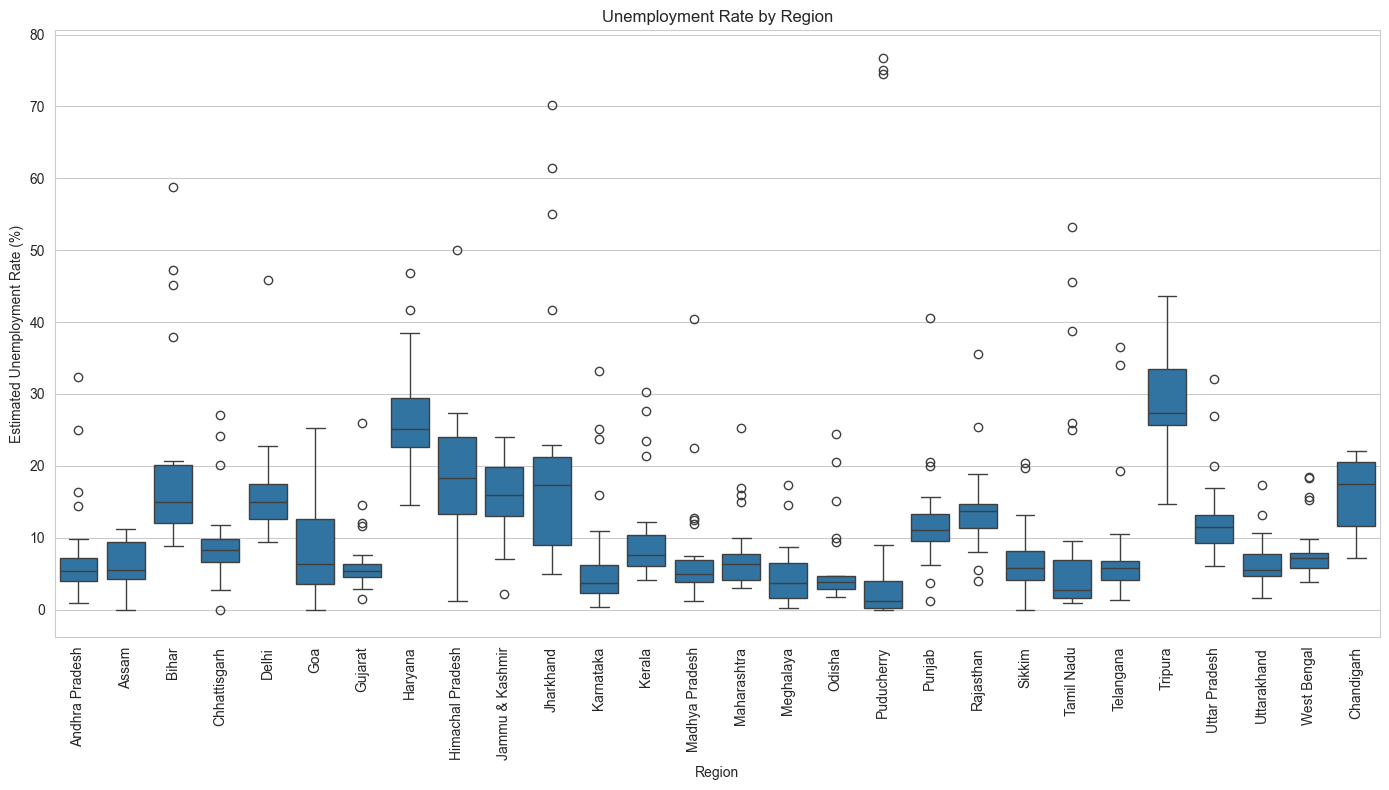

In [7]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x='Region', y='Estimated Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.title('Unemployment Rate by Region')
plt.tight_layout()
plt.show()

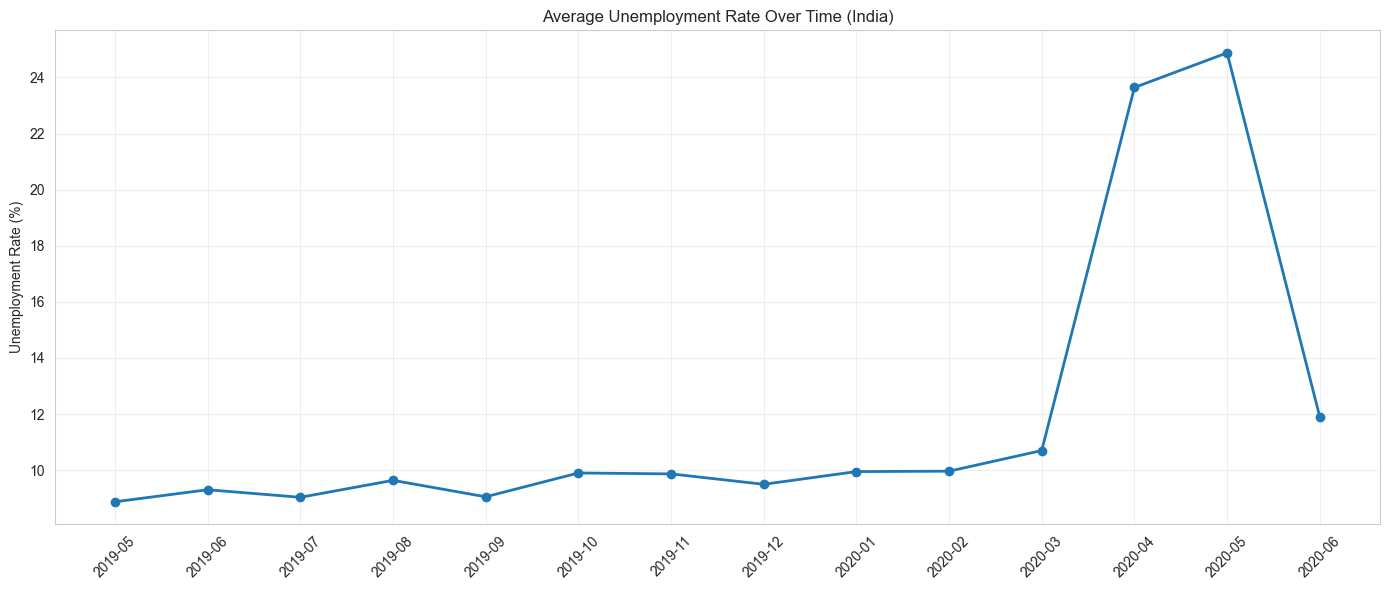

In [8]:
monthly = df.groupby(df['Date'].dt.to_period('M'))['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly.index.astype(str), monthly.values, marker='o', linewidth=2)
plt.xticks(rotation=45)
plt.ylabel('Unemployment Rate (%)')
plt.title('Average Unemployment Rate Over Time (India)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. COVID-19 Impact Analysis

In [9]:
pre_covid = df[df['Date'] < '2020-03-01']['Estimated Unemployment Rate (%)'].mean()
during_covid = df[df['Date'] >= '2020-03-01']['Estimated Unemployment Rate (%)'].mean()
peak = df.loc[df['Estimated Unemployment Rate (%)'].idxmax()]

print(f'Avg unemployment before COVID-19 (pre-March 2020): {pre_covid:.2f}%')
print(f'Avg unemployment during COVID-19 (March 2020+):   {during_covid:.2f}%')
print(f'Peak unemployment: {peak["Estimated Unemployment Rate (%)"]:.2f}% in {peak["Region"]} on {peak["Date"].date()}')

Avg unemployment before COVID-19 (pre-March 2020): 9.51%
Avg unemployment during COVID-19 (March 2020+):   17.77%
Peak unemployment: 76.74% in Puducherry on 2020-04-30


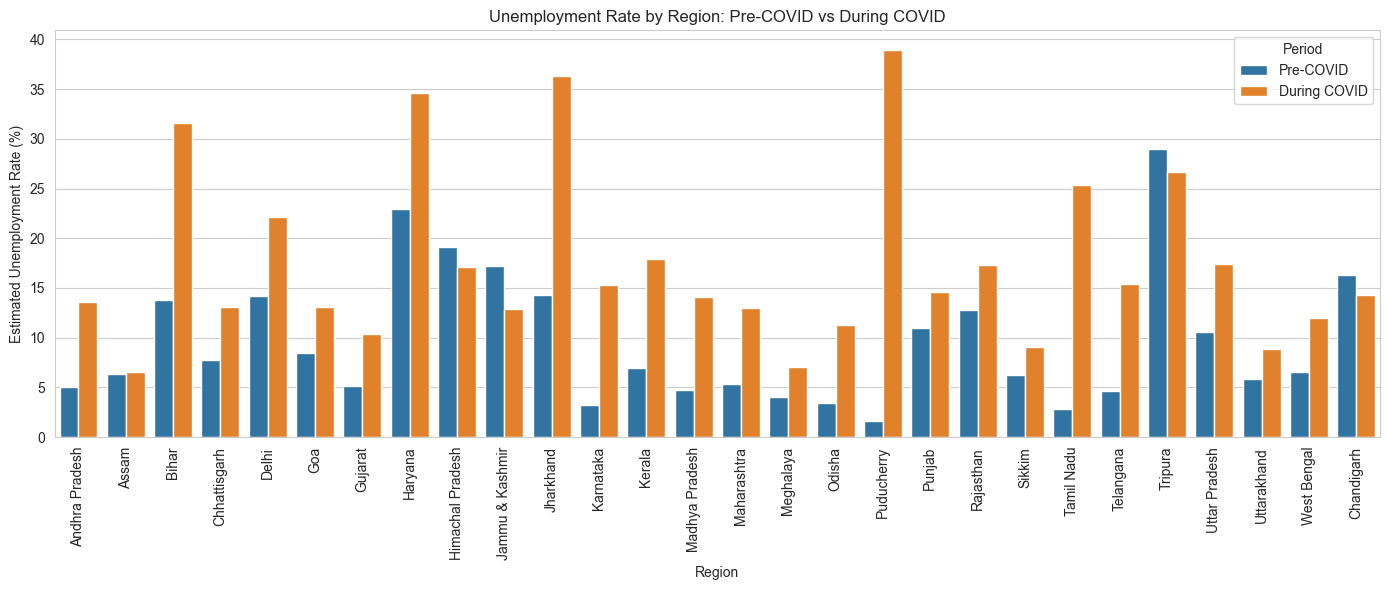

In [10]:
df['Period'] = np.where(df['Date'] < '2020-03-01', 'Pre-COVID', 'During COVID')

plt.figure(figsize=(14, 6))
sns.barplot(data=df, x='Region', y='Estimated Unemployment Rate (%)', hue='Period', errorbar=None)
plt.xticks(rotation=90)
plt.title('Unemployment Rate by Region: Pre-COVID vs During COVID')
plt.legend(title='Period')
plt.tight_layout()
plt.show()

---
## 4. Rural vs Urban Analysis

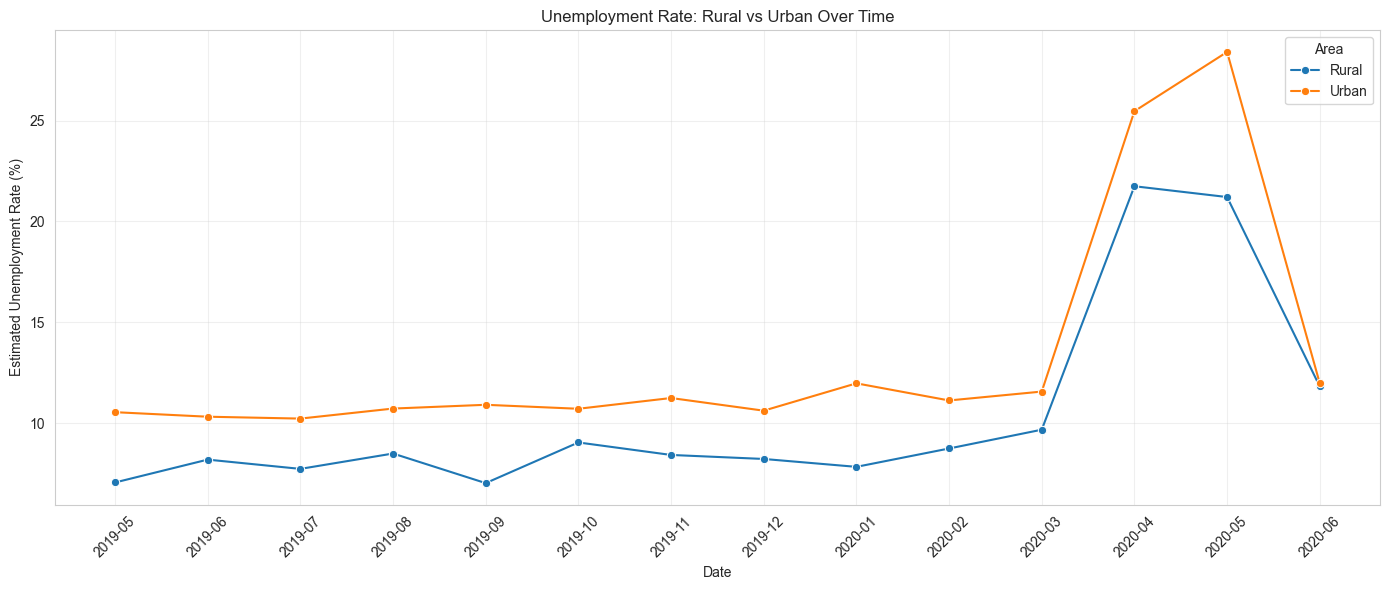

In [11]:
area_monthly = df.groupby(['Area', df['Date'].dt.to_period('M')])['Estimated Unemployment Rate (%)'].mean().reset_index()
area_monthly['Date'] = area_monthly['Date'].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(data=area_monthly, x='Date', y='Estimated Unemployment Rate (%)', hue='Area', marker='o')
plt.xticks(rotation=45)
plt.title('Unemployment Rate: Rural vs Urban Over Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
area_stats = df.groupby('Area')['Estimated Unemployment Rate (%)'].agg(['mean', 'std', 'max'])
print('Rural vs Urban Unemployment Statistics:')
area_stats

Rural vs Urban Unemployment Statistics:


,mean,std,max
Area,,,
Rural,10.324791,10.038895,74.51
Urban,13.166614,11.165444,76.74


---
## 5. Top Affected Regions

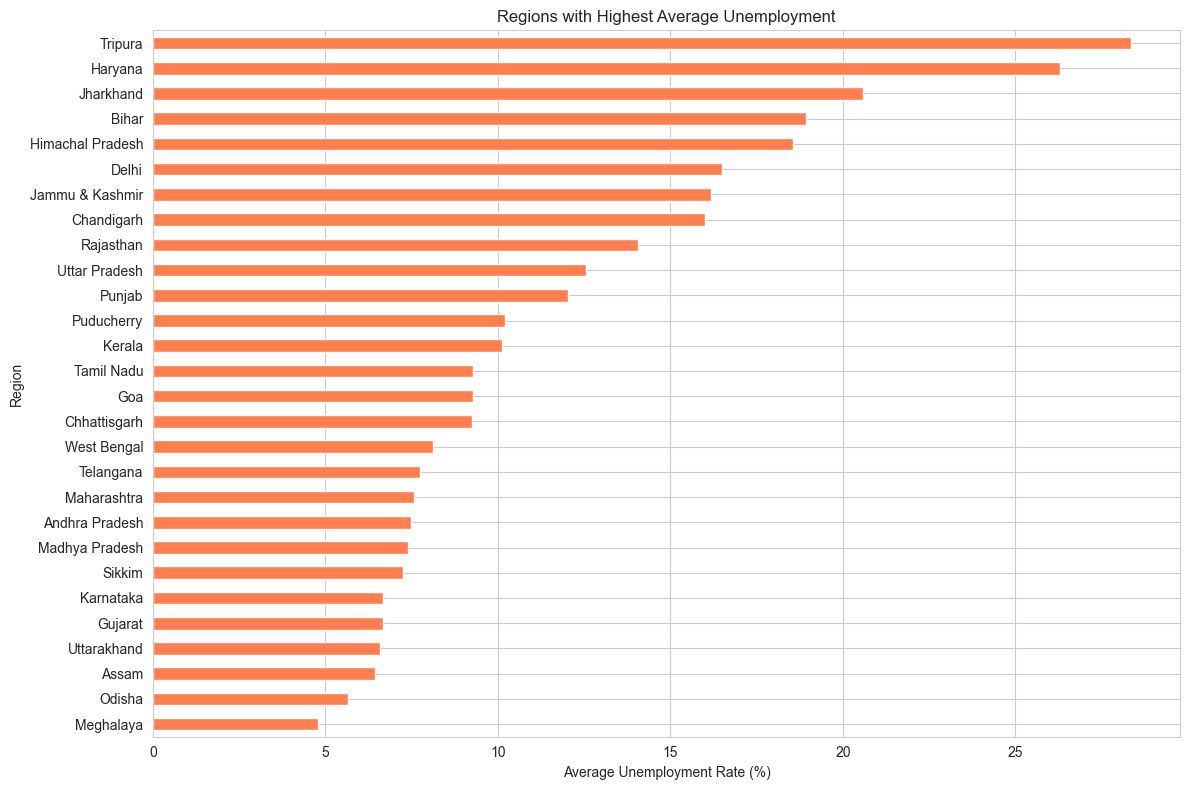

In [13]:
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
region_avg.plot(kind='barh', color='coral')
plt.xlabel('Average Unemployment Rate (%)')
plt.title('Regions with Highest Average Unemployment')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

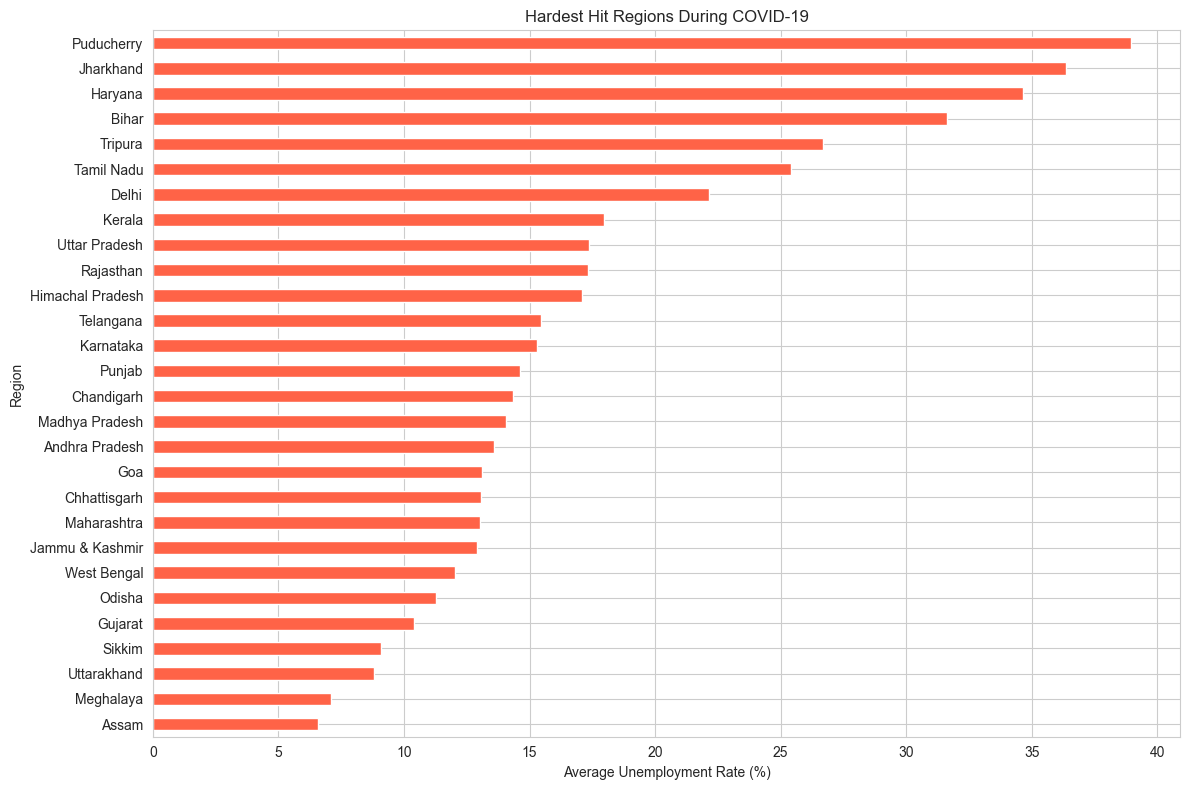

In [14]:
region_covid_impact = df[df['Date'] >= '2020-03-01'].groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
region_covid_impact.plot(kind='barh', color='tomato')
plt.xlabel('Average Unemployment Rate (%)')
plt.title('Hardest Hit Regions During COVID-19')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 6. Correlation Analysis

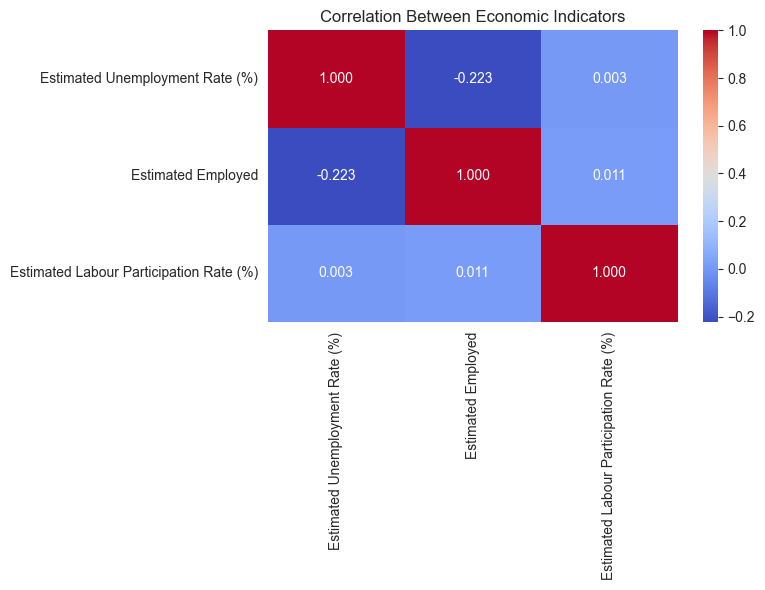

In [15]:
num_cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Correlation Between Economic Indicators')
plt.tight_layout()
plt.show()